In [1]:
import json

import numpy as np
import simpeg
from discretize import TensorMesh
from matplotlib import pyplot as plt
from pymatsolver import Solver
from simpeg import inverse_problem, maps
from simpeg.electromagnetics import time_domain as tdem
from simpeg.electromagnetics.utils.em1d_utils import (
    get_vertical_discretization,
)
from simpeg.regularization import Sparse
from simpeg.utils import plot_1d_layer_model as plot_1d


In [2]:
thickness = get_vertical_discretization(21, 2, 1.17)

>> Depth from the surface to the base of the bottom layer is 306.3m


In [3]:
hz = np.r_[thickness, thickness[-1]]
n_layer = len(hz)
nP = 1 * n_layer
sigma_map = maps.ExpMap(nP=nP)

In [4]:
# T19110 972 th sounding
m1 = [
    9.63148818,
    10.17107292,
    11.25610918,
    12.79577163,
    14.72469571,
    16.97856423,
    19.4875978,
    22.19062404,
    25.02924308,
    27.9363652,
    30.8608197,
    33.73006727,
    36.42154367,
    38.76070617,
    40.456483,
    41.16868033,
    40.66133887,
    38.97401131,
    36.54420735,
    34.00380332,
    31.93330634,
    30.63045525,
]
d1 = np.array(
    [
        -1.69663323e-09,
        -1.24710029e-09,
        -8.73494198e-10,
        -6.49202490e-10,
        -4.99531363e-10,
        -3.90600302e-10,
        -3.14503773e-10,
        -2.56667979e-10,
        -2.13902300e-10,
        -1.74148605e-10,
        -1.35714572e-10,
        -1.07670798e-10,
        -8.78254569e-11,
        -7.00912070e-11,
        -5.42463666e-11,
        -4.55915903e-11,
        -3.59651980e-11,
        -2.91734003e-11,
        -2.26381588e-11,
        -1.43485912e-11,
        -9.34586868e-12,
        -8.55815929e-12,
    ]
)

# T19110 2072 th sounding
m2 = [
    43.60847219,
    42.65065163,
    40.85641459,
    38.4604121,
    35.65712399,
    32.57809339,
    29.34689838,
    26.07741926,
    22.86394495,
    19.79965353,
    16.99369191,
    14.58913004,
    12.7837791,
    11.79191843,
    11.79772506,
    12.66040673,
    13.83366095,
    14.57929606,
    14.59978979,
    14.25485958,
    14.0049699,
    13.95772044,
]
d2 = np.array(
    [
        -1.11803508e-09,
        -8.44418709e-10,
        -6.20985908e-10,
        -4.88576809e-10,
        -3.99988978e-10,
        -3.36059151e-10,
        -2.88986302e-10,
        -2.50609302e-10,
        -2.19221546e-10,
        -1.87375835e-10,
        -1.56265261e-10,
        -1.28995036e-10,
        -1.08350882e-10,
        -9.10631164e-11,
        -7.71108536e-11,
        -6.59532051e-11,
        -5.37463413e-11,
        -4.32486238e-11,
        -3.58261900e-11,
        -2.81850505e-11,
        -2.27254885e-11,
        -1.69651609e-11,
    ]
)

# L10051, 224 th sounding
m3 = [
    43.81728817,
    42.57194312,
    40.37695455,
    37.44482777,
    33.86254969,
    29.69366515,
    25.05296053,
    20.18562244,
    15.57123765,
    11.88377367,
    9.6453006,
    9.03170756,
    10.09772589,
    12.90617897,
    16.77522594,
    19.92504766,
    20.74293808,
    19.33928613,
    17.17501988,
    15.55024086,
    14.85148158,
    14.75013369,
]
d3 = np.array(
    [
        -1.37475334e-09,
        -1.10279498e-09,
        -8.66564125e-10,
        -7.06151787e-10,
        -5.83222002e-10,
        -4.91750993e-10,
        -4.24256785e-10,
        -3.65942865e-10,
        -3.17365283e-10,
        -2.65697993e-10,
        -2.20983819e-10,
        -1.83810101e-10,
        -1.56528481e-10,
        -1.32076407e-10,
        -1.08883441e-10,
        -8.88984423e-11,
        -7.33777511e-11,
        -5.82770091e-11,
        -4.64261339e-11,
        -3.61468798e-11,
        -2.88768335e-11,
        -1.85408003e-11,
    ]
)

In [5]:
alt = 30.0

In [6]:
source_xy = np.array([0.0, 0.0])
source_orientation = "z"
receiver_xy = np.array([0.0, 0.0])
receiver_orientation = "z"

In [7]:
with open("../data/atem.json", "r") as f:
    tmp = json.load(f)
f.close()
channels = np.asarray(tmp["channels"])[3:25] * 1e-6

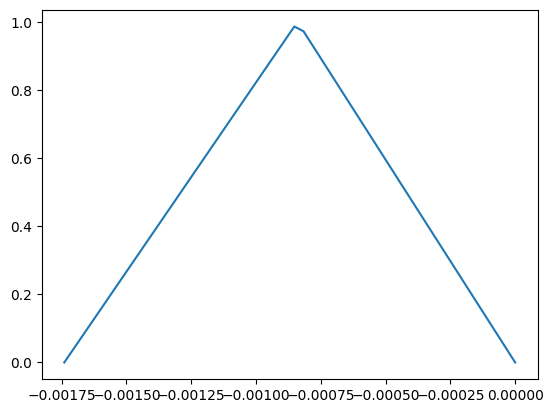

In [8]:
# Waveform
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0
waveform = tdem.sources.TriangularWaveform(start_time, off_time, peak_time)
current_times = np.linspace(start_time, off_time)
currents = [waveform.eval(t) for t in current_times]
plt.plot(current_times, currents)

In [9]:
# Receiver list
receiver_list = []
receiver_list.append(
    tdem.receivers.PointMagneticFluxTimeDerivative(
        np.r_[0, 0, alt], channels, orientation=receiver_orientation
    )
)

# Sources
source_list = [
    tdem.sources.CircularLoop(
        receiver_list=receiver_list,
        location=np.r_[source_xy, alt],
        orientation=source_orientation,
        waveform=waveform,
        current=1,
        radius=5,
    )
]

# Survey
survey = tdem.Survey(source_list)

In [10]:
simulation_L2 = tdem.Simulation1DLayered(
    survey=survey, thicknesses=thickness, sigmaMap=sigma_map, solver=Solver
)

In [11]:
def positive_r(x):
    x = np.asarray(x)
    return x[x > 0]

In [12]:
obs1 = simulation_L2.dpred(np.log(1 / np.array(m1)))
obs2 = simulation_L2.dpred(np.log(1 / np.array(m2)))
obs3 = simulation_L2.dpred(np.log(1 / np.array(m3)))


In [13]:
obs1_noise = obs1 * (1 + np.random.normal(0, 0.05, obs1.shape))
obs2_noise = obs2 * (1 + np.random.normal(0, 0.05, obs2.shape))
obs3_noise = obs3 * (1 + np.random.normal(0, 0.05, obs3.shape))

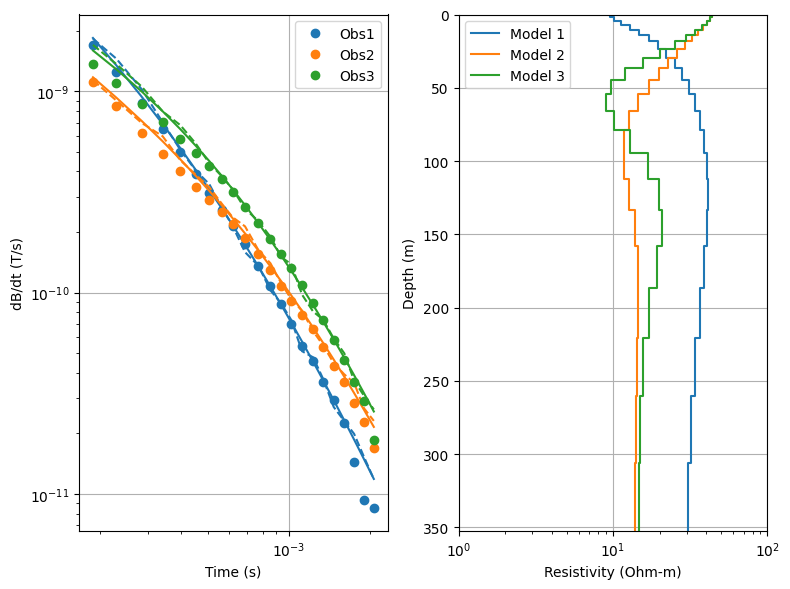

In [14]:
plt.figure(figsize=(8, 6))
plt.subplot(121)
plt.loglog(channels, positive_r(-obs1), c="C0")
plt.loglog(channels, positive_r(-obs1_noise), ls="--", c="C0")
plt.loglog(channels, positive_r(-d1), "o", c="C0", label="Obs1")
plt.loglog(channels, positive_r(-obs2), c="C1")
plt.loglog(channels, positive_r(-obs2_noise), ls="--", c="C1")
plt.loglog(channels, positive_r(-d2), "o", c="C1", label="Obs2")
plt.loglog(channels, positive_r(-obs3), c="C2")
plt.loglog(channels, positive_r(-obs3_noise), ls="--", c="C2")
plt.loglog(channels, positive_r(-d3), "o", c="C2", label="Obs3")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("dB/dt (T/s)")
plt.grid()
plt.subplot(122)
plot_1d(
    thicknesses=thickness,
    values=m1,
    ax=plt.gca(),
    scale="log",
    plot_elevation=False,
    label="Model 1",
)
plot_1d(
    thicknesses=thickness,
    values=m2,
    ax=plt.gca(),
    scale="log",
    plot_elevation=False,
    label="Model 2",
)
plot_1d(
    thicknesses=thickness,
    values=m3,
    ax=plt.gca(),
    scale="log",
    plot_elevation=False,
    label="Model 3",
)
plt.xlabel("Resistivity (Ohm-m)")
plt.legend()
plt.xlim(1, 100)
plt.grid()
plt.tight_layout()
plt.show()

In [15]:
data_object1 = simpeg.data.Data(
    survey,
    dobs=obs1_noise,
    standard_deviation=0.05 * np.abs(obs1_noise) * np.ones(np.shape(obs1_noise)),
)
data_object2 = simpeg.data.Data(
    survey,
    dobs=obs2_noise,
    standard_deviation=0.05 * np.abs(obs2_noise) * np.ones(np.shape(obs2_noise)),
)
data_object3 = simpeg.data.Data(
    survey,
    dobs=obs3_noise,
    standard_deviation=0.05 * np.abs(obs3_noise) * np.ones(np.shape(obs3_noise)),
)

In [16]:
dmis_data1 = simpeg.data_misfit.L2DataMisfit(
    simulation=simulation_L2, data=data_object1
)
dmis_data2 = simpeg.data_misfit.L2DataMisfit(
    simulation=simulation_L2, data=data_object2
)
dmis_data3 = simpeg.data_misfit.L2DataMisfit(
    simulation=simulation_L2, data=data_object3
)

In [17]:
# Define 1D cell widths
h = np.r_[thickness, thickness[-1]]
h = np.flipud(h)

# Create regularization mesh
regularization_mesh = TensorMesh([h], "N")
print(regularization_mesh)


  TensorMesh: 22 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     22       -352.49          0.00      2.00     46.21    1.17




In [18]:
def make_opt():
    opt = simpeg.optimization.ProjectedGNCG(maxIter=30, maxIterCG=50)
    opt.lower = np.log(2e-2)
    opt.upper = np.log(1)
    return opt

In [19]:
def make_reg():
    return Sparse(
        regularization_mesh,
        alpha_s=0,
        alpha_x=0.5,
        reference_model_in_smooth=False,
        norms=[2.0, 0.0],
    )


# ref_resis = 20.0
# reg_irls = Sparse(
#     regularization_mesh,
#     alpha_s=50,
#     alpha_x=1.,
#     reference_model_in_smooth=True,
#     reference_model=np.log(1.0/ref_resis)* np.ones(nP),
#     norms=[2.0, 0.0],
# )

In [20]:
inv_prob_irls1 = inverse_problem.BaseInvProblem(dmis_data1, make_reg(), make_opt())
inv_prob_irls2 = inverse_problem.BaseInvProblem(dmis_data2, make_reg(), make_opt())
inv_prob_irls3 = inverse_problem.BaseInvProblem(dmis_data3, make_reg(), make_opt())

In [21]:
def make_directives():
    beta = simpeg.directives.BetaSchedule(coolingFactor=2, coolingRate=1)
    betaest = simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1)
    target = simpeg.directives.TargetMisfit(chifact=1.0)
    precond = simpeg.directives.UpdatePreconditioner()
    save_model_dict = simpeg.directives.SaveOutputDictEveryIteration()
    save_model_dict.outDict = {}
    return beta, betaest, target, precond, save_model_dict

In [22]:
def make_update_irls():
    update_irls = simpeg.directives.Update_IRLS(
        coolingFactor=2,
        coolingRate=1,
        f_min_change=1e-5,
        max_irls_iterations=50,
        chifact_start=2.5,
        chifact_target=2.5,
    )
    update_irls.coolEpsFact = 2.0
    return update_irls

In [23]:
res0 = 10.0
m0 = np.ones(nP) * np.log(1.0 / res0)

In [24]:
def run_inversion(inv_prob, m0):
    beta, betaest, target, precond, save_model_dict = make_directives()
    update_irls = make_update_irls()
    inv = simpeg.inversion.BaseInversion(
        inv_prob,
        directiveList=[
            update_irls,
            betaest,
            beta,
            precond,
            save_model_dict,
            # target
        ],
    )
    inv_prob.counter = inv_prob.opt.counter = simpeg.utils.Counter()
    inv_prob.opt.LSshorten = 0.5
    inv_prob.opt.remember("xc")
    a = inv.run(m0)
    return inv, save_model_dict, a


inv1, r1, a1 = run_inversion(inv_prob_irls1, m0)
inv2, r2, a2 = run_inversion(inv_prob_irls2, m0)
inv3, r3, a3 = run_inversion(inv_prob_irls3, m0)


Running inversion with SimPEG v0.22.2.dev14+g7c7f1dc80
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DLayered problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  1.57e+04  2.80e+04  1.78e-32  2.80e+04    8.40e+00      0              
   1  3.92e+03  1.57e+03  4.72e-04  1.58e+03    7.45e+00      0              
   2  9.80e+02  6.84e+01  3.28e-03  7.16e+01    7.22e+00      0   Skip BFGS  
Reached starting chifact with l2-norm regularization: Start IRLS steps...
irls_th

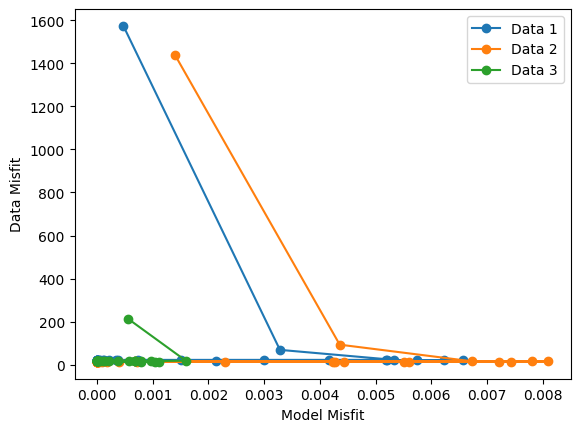

In [25]:
for r, label in [(r1, "Data 1"), (r2, "Data 2"), (r3, "Data 3")]:
    phim = [r.outDict[i]["phi_m"] for i in range(1, len(r.outDict) + 1)]
    phid = [r.outDict[i]["phi_d"] for i in range(1, len(r.outDict) + 1)]
    plt.plot(phim, phid, "o-", label=label)
plt.xlabel("Model Misfit")
plt.ylabel("Data Misfit")
plt.legend()

In [26]:
r1.outDict.keys(), r2.outDict.keys(), r3.outDict.keys()

(dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]),
 dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
 dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]))

In [27]:
runs = [(r1, obs1_noise, m1), (r2, obs2_noise, m2), (r3, obs3_noise, m3)]
# each run's outDict may have a different number of iterations
iterations1, iterations2, iterations3 = (sorted(r.outDict.keys()) for r, _, _ in runs)

In [28]:
import ipywidgets as widgets
from IPython.display import display


def plot_iteration(r, obs_noise, model_true, label, i):
    fig, (ax_data, ax_model) = plt.subplots(1, 2, figsize=(8, 4))
    dpred = r.outDict[i]["dpred"]
    mpred_ = 1.0 / np.exp(r.outDict[i]["m"])
    ax_data.loglog(channels, positive_r(-obs_noise), "o")
    ax_data.loglog(channels, positive_r(-dpred), ls="-")
    ax_data.set_title(f"{label} (iter {i})")
    ax_data.legend(["Observed", "Predicted"])
    ax_data.grid()
    plot_1d(
        thicknesses=thickness,
        values=model_true,
        ax=ax_model,
        scale="log",
        plot_elevation=False,
    )
    plot_1d(
        thicknesses=thickness,
        values=mpred_,
        ax=ax_model,
        scale="log",
        plot_elevation=False,
    )
    ax_model.set_xlim(1e-1, 200)
    ax_model.legend(["True", "Predicted"])
    ax_model.grid()
    plt.tight_layout()
    plt.show()

In [29]:
widgets.interact(
    lambda i: plot_iteration(r1, obs1_noise, m1, "Data 1", i),
    i=widgets.IntSlider(
        min=min(iterations1), max=max(iterations1), step=1, value=max(iterations1)
    ),
)

interactive(children=(IntSlider(value=28, description='i', max=28, min=1), Output()), _dom_classes=('widget-in…

<function __main__.<lambda>(i)>

In [30]:
widgets.interact(
    lambda i: plot_iteration(r2, obs2_noise, m2, "Data 2", i),
    i=widgets.IntSlider(
        min=min(iterations2), max=max(iterations2), step=1, value=max(iterations2)
    ),
)

interactive(children=(IntSlider(value=30, description='i', max=30, min=1), Output()), _dom_classes=('widget-in…

<function __main__.<lambda>(i)>

In [31]:
widgets.interact(
    lambda i: plot_iteration(r3, obs3_noise, m3, "Data 3", i),
    i=widgets.IntSlider(
        min=min(iterations3), max=max(iterations3), step=1, value=max(iterations3)
    ),
)

interactive(children=(IntSlider(value=30, description='i', max=30, min=1), Output()), _dom_classes=('widget-in…

<function __main__.<lambda>(i)>